In [1]:
import maboss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Simulation with pyMaBoSS

In [2]:
sim_press = maboss.PopSimulation("BCancerControlPress/BasicCancerControlPress.pbnd", "BCancerControlPress/BasicCancerControlPress.cfg")
res_press = sim_press.run(workdir="BCancerControlPress", prefix="ResBCancerControlPress")

In [3]:
sim_nopress = maboss.PopSimulation("BCancerControlPress/BasicCancerControlPress.pbnd", "BCancerControlPress/BasicCancerNoPress.cfg")
res_nopress = sim_nopress.run(workdir="BCancerControlPress", prefix="ResBCancerNoPress")

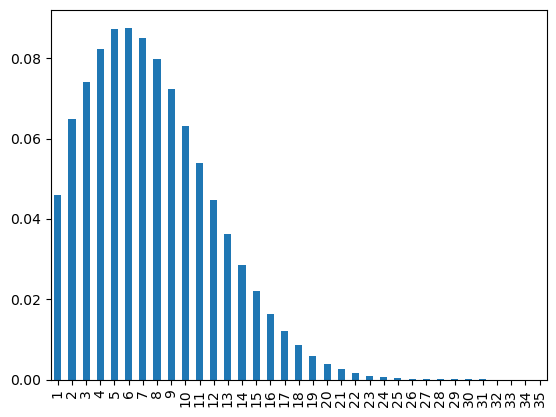

In [4]:
res_press.plot_last_state_dist("Oncogene")

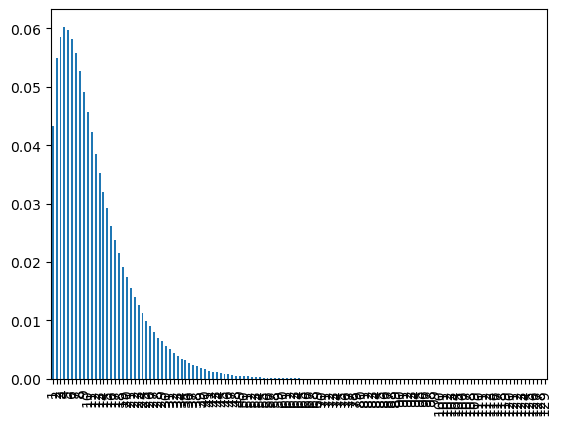

In [5]:
res_nopress.plot_last_state_dist("Oncogene")

In [6]:
logdist_press = res_press.get_last_log_nb_dist(num=40, vmin=7, vmax=10000)
logdist_nopress = res_nopress.get_last_log_nb_dist(num=40, vmin=7, vmax=10000)

<Axes: >

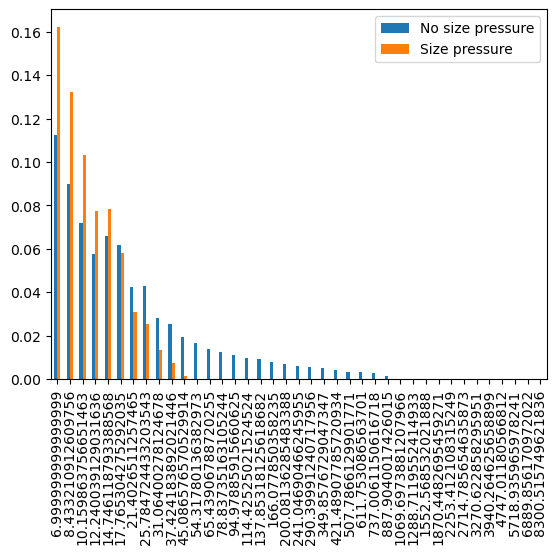

In [7]:
pd.DataFrame([logdist_nopress, logdist_press], index=["No size pressure", "Size pressure"]).transpose().plot.bar()

<Axes: >

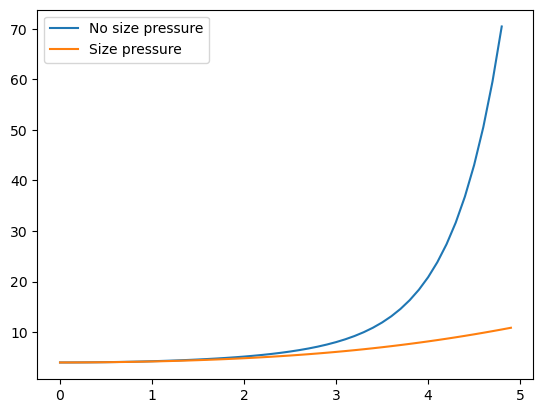

In [8]:
pd.DataFrame([res_nopress.get_simple_popsize(), res_press.get_simple_popsize()], index=["No size pressure", "Size pressure"]).transpose().plot()

<Axes: >

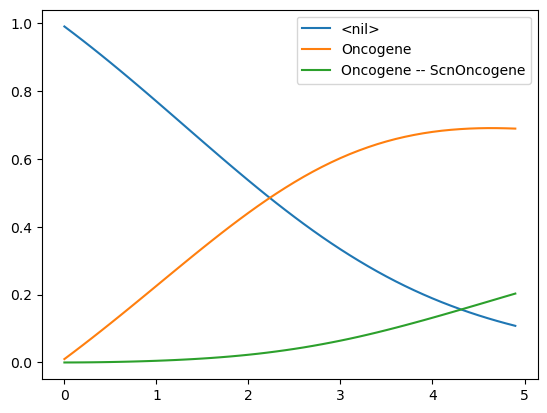

In [9]:
res_press.get_simple_states_probtraj().plot()

<Axes: >

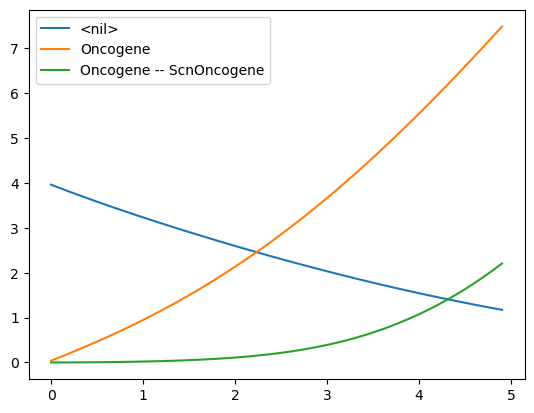

In [10]:
res_press.get_simple_states_popsize().plot()

In [11]:
sim_press_8cells = maboss.PopSimulation("BCancerControlPress/BasicCancerControlPress.pbnd", "BCancerControlPress/BasicCancerControlPress8Cells.cfg")
res_press_8cells = sim_press_8cells.run(workdir="BCancerControlPress", prefix="ResBCancerControlPress8Cells")

In [12]:
sim_nopress_8cells = maboss.PopSimulation("BCancerControlPress/BasicCancerControlPress.pbnd", "BCancerControlPress/BasicCancerNoPress8Cells.cfg")
res_nopress_8cells = sim_nopress_8cells.run(workdir="BCancerControlPress", prefix="ResBCancerNoPress8Cells")

<Axes: >

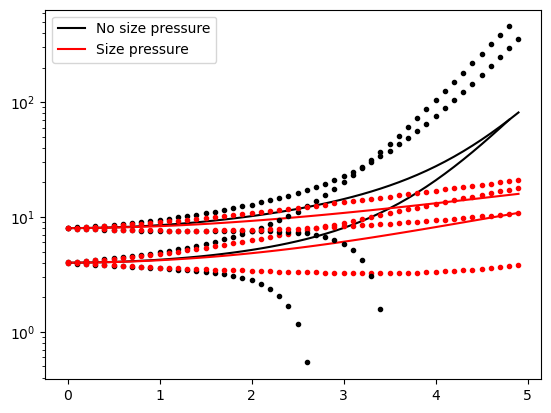

In [13]:
fig, ax = plt.subplots()

pd.DataFrame(
    [
        res_nopress.get_simple_popsize(),
        res_press.get_simple_popsize()
    ], 
    index=["No size pressure", "Size pressure"]
).transpose().plot(
    color=['black', 'red'],
    logy=True,
    ax=ax
)

pd.DataFrame(
    [
        res_nopress_8cells.get_simple_popsize(),
        res_press_8cells.get_simple_popsize()
    ], 
).transpose().plot(
    color=['black', 'red'],
    logy=True,
    ax=ax,
    legend=False
)
pd.DataFrame(
    [
        res_nopress.get_simple_popsize()-(res_nopress.get_simple_popsize_errors()**0.5), res_nopress.get_simple_popsize()+(res_nopress.get_simple_popsize_errors()**0.5), 
        res_press.get_simple_popsize()-(res_press.get_simple_popsize_errors()**0.5), res_press.get_simple_popsize()+(res_press.get_simple_popsize_errors()**0.5), 
    ], 
).transpose().plot(
    color=['black', 'black', 'red', 'red'],
    logy=True,
    legend=False,
    ax=ax, style='.'
)

pd.DataFrame(
    [
        res_nopress_8cells.get_simple_popsize()-(res_nopress_8cells.get_simple_popsize_errors()**0.5), res_nopress_8cells.get_simple_popsize()+(res_nopress_8cells.get_simple_popsize_errors()**0.5), 
        res_press_8cells.get_simple_popsize()-(res_press_8cells.get_simple_popsize_errors()**0.5), res_press_8cells.get_simple_popsize()+(res_press_8cells.get_simple_popsize_errors()**0.5), 
    ], 
).transpose().plot(
    color=['black', 'black', 'red', 'red'],
    logy=True,
    legend=False,
    ax=ax, style='.'
)

<Axes: >

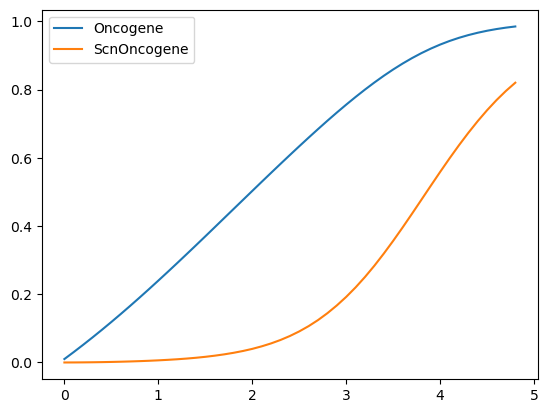

In [14]:
res_nopress.get_simple_nodes_probtraj().plot()

<Axes: >

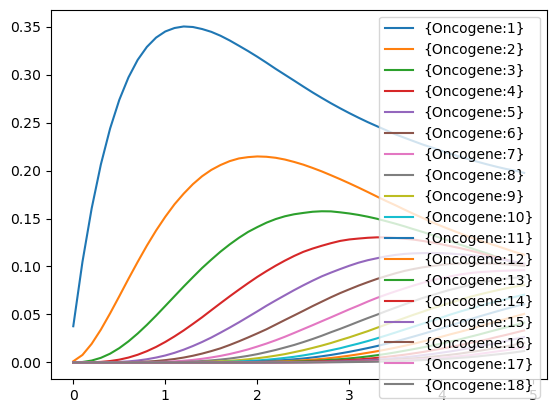

In [15]:
res_press.get_nodes_probtraj(nodes=["Oncogene"],prob_cutoff=1e-2).plot()

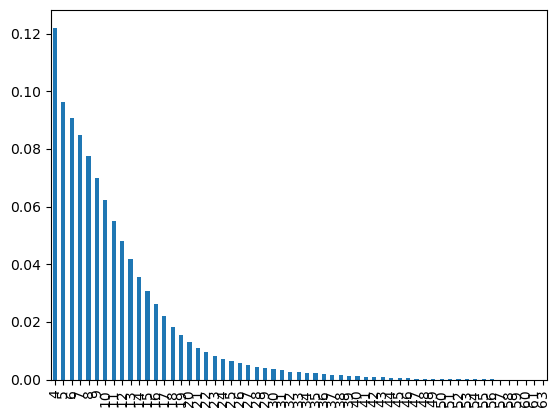

In [16]:
res_press.plot_last_nb_dist()

<Axes: >

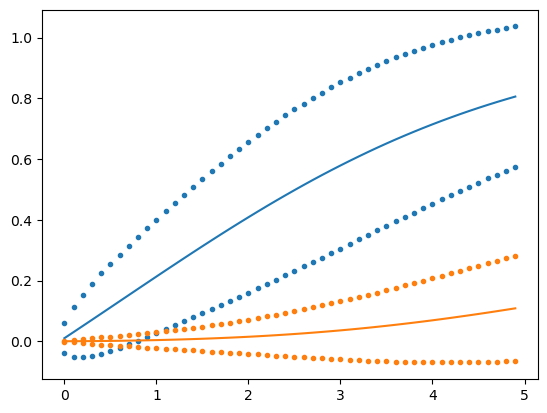

In [17]:
res_press.get_activity_ratio_expected("Oncogene").plot(color=["C0"])
(res_press.get_activity_ratio_expected("Oncogene")+res_press.get_activity_ratio_stdev("Oncogene")).plot(style=".", color=["C0"])
(res_press.get_activity_ratio_expected("Oncogene")-res_press.get_activity_ratio_stdev("Oncogene")).plot(style=".", color=["C0"])
res_press.get_activity_ratio_expected("ScnOncogene").plot(color=["C1"])
(res_press.get_activity_ratio_expected("ScnOncogene")+res_press.get_activity_ratio_stdev("ScnOncogene")).plot(style=".", color=["C1"])
(res_press.get_activity_ratio_expected("ScnOncogene")-res_press.get_activity_ratio_stdev("ScnOncogene")).plot(style=".", color=["C1"])

In [18]:
sim_press_8cells_long = maboss.PopSimulation("BCancerControlPress/BasicCancerControlPress.pbnd", "BCancerControlPress/BasicCancerControlPress8CellsLong.cfg")
res_press_8cells_long = sim_press_8cells_long.run(workdir="BCancerControlPress", prefix="ResBCancerControlPress8CellsLong")

<Axes: >

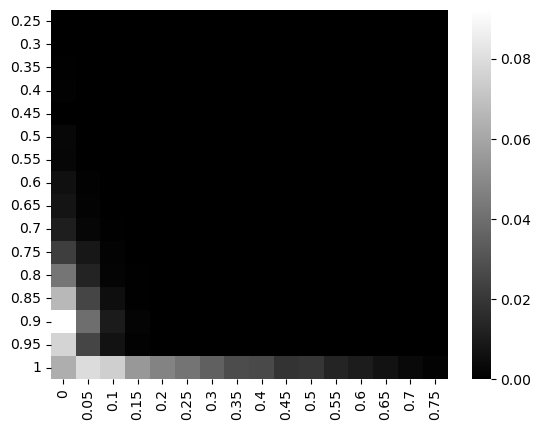

In [19]:
heatmap = res_press_8cells_long.get_activity_ratio_nodes("Oncogene", "ScnOncogene", time=7.0, nbins=20)
sns.heatmap(heatmap.iloc[5:, :16], cmap="gray")

<Axes: >

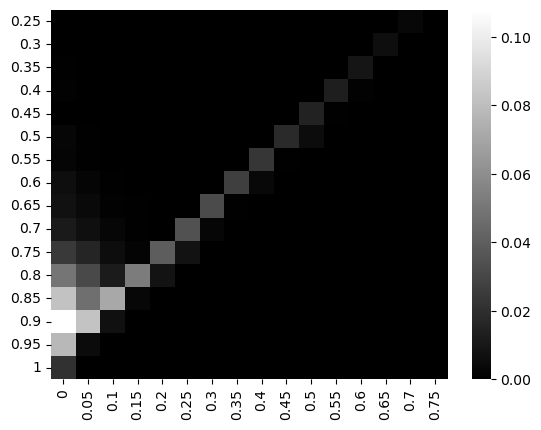

In [20]:
heatmap = res_press_8cells_long.get_activity_ratio_states("Oncogene", "Oncogene -- ScnOncogene", time=7.0, nbins=20)
sns.heatmap(heatmap.iloc[5:, :16], cmap="gray")